# Risk Modeling and Index Tracking Exercise

## Goal of the Notebook

In this notebook, we will build a portfolio from a chosen universe of stocks that attempts to track the S&P 500 as closely as possible.

Instead of choosing weights manually, we will solve for portfolio weights that minimize **tracking error** relative to the benchmark.

The benchmark will be the S&P 500, proxied by an ETF such as SPY or VOO.

---

## Main Objective

Let:

- $r_p$ = portfolio return
- $r_b$ = benchmark return

The active return is:

$$
r_A = r_p - r_b
$$

Tracking error is the standard deviation of active returns:

$$
TE = \sigma(r_p - r_b)
$$

The optimization problem is:

$$
\min_h Var(r_p - r_b)
$$

where $h$ is the vector of portfolio weights.

---

## What We Will Build

We will:

1. Define a universe of stocks.
2. Download historical returns.
3. Define the S&P 500 benchmark.
4. Estimate stock betas and residual returns.
5. Build a portfolio that minimizes tracking error.
6. Calculate tracking error.
7. Decompose risk into systematic and specific components.

---

## Connection to Grinold & Kahn Chapter 3

This exercise applies the chapter's risk ideas directly:

$$
r_i = \beta_i r_M + \theta_i
$$

where:

- $\beta_i r_M$ = systematic return
- $\theta_i$ = specific return

We will use this framework to understand not only how closely our portfolio tracks the S&P 500, but also why tracking error remains.

# Step 1: Define the Stock Universe

Our first task is to define the investable universe.

Because the goal is to track the S&P 500, we want a universe that is diversified across sectors rather than concentrated in only technology or mega-cap growth stocks.

We will select:

$
3 \text{ stocks per sector} \times 11 \text{ sectors} = 33 \text{ stocks}
$

Each sector will contain the three largest S&P 500 companies by market capitalization.

This gives us a manageable but diversified universe for studying tracking error, beta, residual risk, and portfolio optimization.

The S&P 500 is free-float market-cap weighted, so larger companies have greater importance in the benchmark. For that reason, using the largest companies in each sector is a natural first choice for building a simplified index-tracking universe.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

universe_dict = {
    "Communication Services": ["GOOG", "META", "NFLX"],
    "Consumer Discretionary": ["AMZN", "TSLA", "HD"],
    "Consumer Staples": ["COST", "WMT", "PG"],
    "Energy": ["XOM", "CVX", "COP"],
    "Financials": ["BRK-B", "JPM", "V"],
    "Health Care": ["LLY", "UNH", "JNJ"],
    "Industrials": ["GE", "CAT", "RTX"],
    "Information Technology": ["NVDA", "MSFT", "AAPL"],
    "Materials": ["LIN", "SHW", "APD"],
    "Utilities": ["NEE", "SO", "DUK"],
}

universe_df = (
    pd.DataFrame(
        [(sector, ticker) for sector, tickers in universe_dict.items() for ticker in tickers],
        columns=["Sector", "Ticker"]
    )
)

universe = universe_df["Ticker"].tolist()

print(f"Number of stocks: {len(universe)}")
display(universe_df)

Number of stocks: 30


,Sector,Ticker
0,Communication Services,GOOG
1,Communication Services,META
2,Communication Services,NFLX
3,Consumer Discretionary,AMZN
4,Consumer Discretionary,TSLA
5,Consumer Discretionary,HD
6,Consumer Staples,COST
7,Consumer Staples,WMT
8,Consumer Staples,PG
9,Energy,XOM


# Step 2: Download Prices and Compute Returns

Now that we have defined our 30-stock universe, we need historical return data.

For each stock, we will download adjusted closing prices. Adjusted prices account for splits and dividends, so they are better for return calculations than raw closing prices.

We will also download SPY as our benchmark proxy for the S&P 500.

From prices, we compute daily simple returns:

\$
r_t = \frac{P_t}{P_{t-1}} - 1
\$

The result will be:

- a stock return matrix \(R\), where each column is one stock,
- a benchmark return series \(r_b\),
- and a combined dataset aligned by date.

This return data will become the input for our tracking-error optimization.

In [10]:
# Step 2: Download prices and compute returns

import pandas as pd
import numpy as np
import yfinance as yf

# -----------------------------
# 1. Define benchmark
# -----------------------------

benchmark = "SPY"

# Combine stock universe and benchmark
all_tickers = universe + [benchmark]

# -----------------------------
# 2. Download adjusted close prices
# -----------------------------

start_date = "2020-01-01"
end_date = None  # None downloads through the most recent available date

prices = yf.download(
    all_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

# Make sure columns are ordered cleanly
prices = prices[all_tickers]

display(prices.head())

Ticker,GOOG,META,NFLX,AMZN,TSLA,HD,COST,WMT,PG,XOM,...,NVDA,MSFT,AAPL,LIN,SHW,APD,NEE,SO,DUK,SPY
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,67.770973,207.953857,32.980999,94.900497,28.684000,188.727631,265.748291,36.289959,104.735352,52.947021,...,5.970754,151.829529,72.333870,192.737991,179.858551,197.348816,51.085968,48.878239,69.947151,296.125214
2020-01-03,67.438416,206.853500,32.590000,93.748497,29.534000,188.100418,265.967163,35.969589,104.030945,52.521370,...,5.875186,149.938980,71.630630,187.726135,177.531006,192.960236,51.449924,48.831406,69.993614,293.882935
2020-01-06,69.101250,210.749313,33.583000,95.143997,30.102667,188.985397,266.040100,35.896366,104.175209,52.924633,...,5.899826,150.326553,72.201393,186.930435,177.203979,192.874893,51.706829,49.026539,70.334267,295.004181
2020-01-07,69.058128,211.205292,33.075001,95.343002,31.270666,187.748199,265.620697,35.563786,103.530243,52.491497,...,5.971251,148.955933,71.861855,187.332870,176.244675,193.694534,51.661865,48.878239,69.892952,294.174622
2020-01-08,69.602341,213.346512,33.925999,94.598503,32.809334,190.557678,268.665741,35.441742,103.971550,51.699898,...,5.982451,151.328568,73.017845,189.674210,179.050171,194.744705,51.638317,48.862617,69.993614,295.742462


In [11]:
# -----------------------------
# 3. Compute daily simple returns
# -----------------------------

returns = prices.pct_change().dropna()

stock_returns = returns[universe]
benchmark_returns = returns[benchmark]

print("Stock return matrix shape:", stock_returns.shape)
print("Benchmark return series shape:", benchmark_returns.shape)

display(stock_returns.head())

Stock return matrix shape: (1636, 30)
Benchmark return series shape: (1636,)


Ticker,GOOG,META,NFLX,AMZN,TSLA,HD,COST,WMT,PG,XOM,...,RTX,NVDA,MSFT,AAPL,LIN,SHW,APD,NEE,SO,DUK
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,-0.004907,-0.005291,-0.011855,-0.012139,0.029633,-0.003323,0.000824,-0.008828,-0.006726,-0.008039,...,0.001371,-0.016006,-0.012452,-0.009722,-0.026003,-0.012941,-0.022238,0.007124,-0.000958,0.000664
2020-01-06,0.024657,0.018834,0.030469,0.014886,0.019255,0.004705,0.000274,-0.002036,0.001387,0.007678,...,0.002152,0.004194,0.002585,0.007968,-0.004239,-0.001842,-0.000442,0.004993,0.003996,0.004867
2020-01-07,-0.000624,0.002164,-0.015127,0.002092,0.038801,-0.006547,-0.001576,-0.009265,-0.006191,-0.008184,...,-0.003189,0.012106,-0.009118,-0.004703,0.002153,-0.005414,0.004250,-0.000870,-0.003025,-0.006275
2020-01-08,0.007880,0.010138,0.025729,-0.007809,0.049205,0.014964,0.011464,-0.003432,0.004263,-0.015081,...,0.001501,0.001876,0.015928,0.016086,0.012498,0.015918,0.005422,-0.000456,-0.000320,0.001440
2020-01-09,0.011044,0.014311,-0.010611,0.004799,-0.021945,0.015330,0.016051,0.010331,0.010938,0.007656,...,0.001499,0.010983,0.012493,0.021241,0.007040,-0.006411,0.023719,0.007836,0.010543,0.002434


In [12]:
# -----------------------------
# 4. Quick check: missing data
# -----------------------------

missing_counts = stock_returns.isna().sum().sort_values(ascending=False)

display(missing_counts)

print("Any missing values?", stock_returns.isna().any().any())

Ticker
GOOG     0
META     0
SO       0
NEE      0
APD      0
SHW      0
LIN      0
AAPL     0
MSFT     0
NVDA     0
RTX      0
CAT      0
GE       0
JNJ      0
UNH      0
LLY      0
V        0
JPM      0
BRK-B    0
COP      0
CVX      0
XOM      0
PG       0
WMT      0
COST     0
HD       0
TSLA     0
AMZN     0
NFLX     0
DUK      0
dtype: int64

Any missing values? False


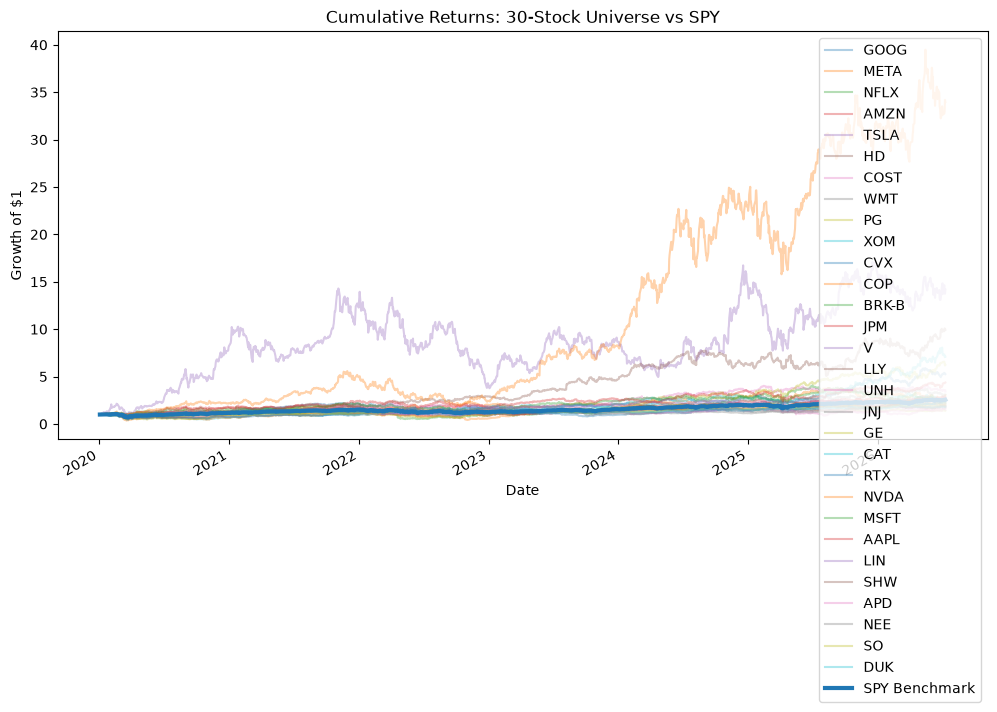

In [13]:
# -----------------------------
# 5. Plot cumulative returns
# -----------------------------

cumulative_stock_returns = (1 + stock_returns).cumprod()
cumulative_benchmark_returns = (1 + benchmark_returns).cumprod()

ax = cumulative_stock_returns.plot(
    figsize=(12, 6),
    alpha=0.35,
    legend=False,
    title="Cumulative Returns: 30-Stock Universe vs SPY"
)

cumulative_benchmark_returns.plot(
    ax=ax,
    linewidth=3,
    label="SPY Benchmark"
)

ax.set_ylabel("Growth of $1")
ax.legend()

# Step 3: Estimate the Single-Factor Risk Model

Chapter 3 models each stock's return as the sum of a systematic component and a specific component.

For stock $i$,

$$
r_i = \beta_i r_M + \theta_i
$$

where

- $r_i$ is the stock return,
- $r_M$ is the market return (SPY),
- $\beta_i$ measures the stock's sensitivity to the market,
- $\theta_i$ is the stock's specific (residual) return.

The beta of each stock is estimated using

$$
\beta_i=\frac{Cov(r_i,r_M)}{Var(r_M)}.
$$

Once beta is known, the residual return is simply the portion of the stock's return not explained by the market:

$$
\theta_i=r_i-\beta_i r_M.
$$

Finally, the variance of these residual returns is

$$
\sigma_{\theta,i}^2=Var(\theta_i).
$$

By the end of this section we will know, for every stock,

- its market exposure ($\beta_i$),
- its daily residual returns ($\theta_i$),
- and its specific variance ($\sigma_{\theta,i}^2$).

These quantities form the building blocks of the risk model developed in Chapter 3.

In [14]:
# Step 3: Estimate the single-factor risk model

# -----------------------------
# 1. Estimate market variance
# -----------------------------

market_var = benchmark_returns.var()

print("Daily market variance:", market_var)
print("Annualized market volatility:", np.sqrt(market_var * 252))

# -----------------------------
# 2. Estimate beta for each stock
# beta_i = Cov(r_i, r_M) / Var(r_M)
# -----------------------------

betas = {}

for ticker in universe:
    cov_i_m = stock_returns[ticker].cov(benchmark_returns)
    beta_i = cov_i_m / market_var
    betas[ticker] = beta_i

betas = pd.Series(betas, name="Beta")

display(betas.sort_values(ascending=False))

# -----------------------------
# 3. Estimate residual returns
# theta_i = r_i - beta_i * r_M
# -----------------------------

residual_returns = stock_returns.copy()

for ticker in universe:
    residual_returns[ticker] = stock_returns[ticker] - betas[ticker] * benchmark_returns

display(residual_returns.head())

# -----------------------------
# 4. Estimate specific variance
# sigma_theta_i^2 = Var(theta_i)
# -----------------------------

specific_vars = residual_returns.var()
specific_vols = np.sqrt(specific_vars * 252)

risk_model_summary = pd.DataFrame({
    "Beta": betas,
    "Specific Variance (Daily)": specific_vars,
    "Specific Volatility (Annualized)": specific_vols
})

risk_model_summary = risk_model_summary.sort_values("Beta", ascending=False)

display(risk_model_summary)

Daily market variance: 0.00016343940285757372
Annualized market volatility: 0.2029451391881771


NVDA     1.800013
TSLA     1.712054
META     1.343698
AAPL     1.186708
GE       1.154894
AMZN     1.141576
GOOG     1.135417
MSFT     1.129731
JPM      1.060381
CAT      1.026510
COP      1.013893
NFLX     0.978480
V        0.965096
HD       0.947269
SHW      0.890764
CVX      0.886640
RTX      0.875906
APD      0.854352
LIN      0.848577
BRK-B    0.741852
XOM      0.741425
UNH      0.731420
NEE      0.720599
COST     0.660999
LLY      0.648004
SO       0.575080
DUK      0.512806
PG       0.473906
WMT      0.465369
JNJ      0.399372
Name: Beta, dtype: float64

Ticker,GOOG,META,NFLX,AMZN,TSLA,HD,COST,WMT,PG,XOM,...,RTX,NVDA,MSFT,AAPL,LIN,SHW,APD,NEE,SO,DUK
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,0.003690,0.004883,-0.004446,-0.003495,0.042597,0.003849,0.005829,-0.005304,-0.003137,-0.002425,...,0.008004,-0.002376,-0.003897,-0.000736,-0.019578,-0.006196,-0.015768,0.012581,0.003396,0.004547
2020-01-06,0.020325,0.013707,0.026736,0.010530,0.012723,0.001091,-0.002248,-0.003811,-0.000421,0.004849,...,-0.001189,-0.002674,-0.001725,0.003441,-0.007476,-0.005241,-0.003702,0.002244,0.001802,0.002910
2020-01-07,0.002569,0.005942,-0.012375,0.005302,0.043615,-0.003883,0.000282,-0.007956,-0.004859,-0.006099,...,-0.000726,0.017168,-0.005941,-0.001366,0.004539,-0.002909,0.006652,0.001157,-0.001408,-0.004833
2020-01-08,0.001829,0.002977,0.020514,-0.013893,0.040080,0.009915,0.007941,-0.005912,0.001737,-0.019032,...,-0.003167,-0.007718,0.009907,0.009762,0.007976,0.011171,0.000868,-0.004296,-0.003385,-0.001293
2020-01-09,0.003346,0.005200,-0.017246,-0.002941,-0.033554,0.008907,0.011569,0.007175,0.007724,0.002629,...,-0.004440,-0.001222,0.004833,0.013194,0.001286,-0.012451,0.017926,0.002950,0.006644,-0.001043


,Beta,Specific Variance (Daily),Specific Volatility (Annualized)
NVDA,1.800013,0.000549,0.371941
TSLA,1.712054,0.001202,0.550393
META,1.343698,0.000464,0.341787
AAPL,1.186708,0.000161,0.201687
GE,1.154894,0.000356,0.299696
AMZN,1.141576,0.000283,0.267153
GOOG,1.135417,0.000200,0.224635
MSFT,1.129731,0.000146,0.192044
JPM,1.060381,0.000195,0.221420
CAT,1.026510,0.000271,0.261351


# Step 4: Construct the Covariance Matrix

The optimizer does not work directly with betas or residual returns.

Instead, it requires the covariance matrix of stock returns.

From Chapter 3,

$$
r_i=\beta_i r_M+\theta_i.
$$

Stacking every stock together gives

$$
r=\beta r_M+\theta.
$$

Taking the covariance of both sides,

$$
Cov(r)=Cov(\beta r_M+\theta).
$$

Expanding the covariance,

$$
Cov(r)
=
Cov(\beta r_M)
+
Cov(\theta),
$$

because the residual returns are assumed to be independent of the market factor.

The covariance of the market component is

$$
Cov(\beta r_M)
=
\beta\beta^T\sigma_M^2,
$$

where

- $\beta$ is the vector of stock betas,
- $\sigma_M^2$ is the variance of the market return.

The covariance of the residual component is

$$
D=
\begin{bmatrix}
\sigma_{\theta,1}^2 & 0 & \cdots & 0\\
0 & \sigma_{\theta,2}^2 & \cdots & 0\\
\vdots & & \ddots & \vdots\\
0 & 0 & \cdots & \sigma_{\theta,n}^2
\end{bmatrix},
$$

a diagonal matrix containing each stock's specific variance.

Putting these together,

$$
\boxed{
\Sigma
=
\beta\beta^T\sigma_M^2
+
D
}
$$

This matrix represents the total covariance between every pair of stocks.

The first term captures covariance created by exposure to the common market factor.

The second term captures each stock's own unique risk.

This covariance matrix will become the input to our portfolio optimization.

In [15]:
# -----------------------------
# 5. Build the single-factor covariance matrix
# Sigma = beta beta^T sigma_M^2 + D
# -----------------------------

beta_vector = betas.loc[universe].values.reshape(-1, 1)

systematic_cov = beta_vector @ beta_vector.T * market_var

specific_cov = np.diag(specific_vars.loc[universe].values)

Sigma = systematic_cov + specific_cov

Sigma = pd.DataFrame(
    Sigma,
    index=universe,
    columns=universe
)

display(Sigma.head())

# -----------------------------
# 6. Check covariance matrix dimensions
# -----------------------------

print("Covariance matrix shape:", Sigma.shape)
print("Number of stocks:", len(universe))

,GOOG,META,NFLX,AMZN,TSLA,HD,COST,WMT,PG,XOM,...,RTX,NVDA,MSFT,AAPL,LIN,SHW,APD,NEE,SO,DUK
GOOG,0.000411,0.000249,0.000182,0.000212,0.000318,0.000176,0.000123,0.000086,0.000088,0.000138,...,0.000163,0.000334,0.000210,0.000220,0.000157,0.000165,0.000159,0.000134,0.000107,0.000095
META,0.000249,0.000759,0.000215,0.000251,0.000376,0.000208,0.000145,0.000102,0.000104,0.000163,...,0.000192,0.000395,0.000248,0.000261,0.000186,0.000196,0.000188,0.000158,0.000126,0.000113
NFLX,0.000182,0.000215,0.000747,0.000183,0.000274,0.000151,0.000106,0.000074,0.000076,0.000119,...,0.000140,0.000288,0.000181,0.000190,0.000136,0.000142,0.000137,0.000115,0.000092,0.000082
AMZN,0.000212,0.000251,0.000183,0.000496,0.000319,0.000177,0.000123,0.000087,0.000088,0.000138,...,0.000163,0.000336,0.000211,0.000221,0.000158,0.000166,0.000159,0.000134,0.000107,0.000096
TSLA,0.000318,0.000376,0.000274,0.000319,0.001681,0.000265,0.000185,0.000130,0.000133,0.000207,...,0.000245,0.000504,0.000316,0.000332,0.000237,0.000249,0.000239,0.000202,0.000161,0.000143


Covariance matrix shape: (30, 30)
Number of stocks: 30


# Step 5: Optimize Portfolio Weights to Minimize Tracking Error

Now that we have constructed the covariance matrix $\Sigma$, we can solve for portfolio weights.

Let $h$ be the vector of portfolio weights:

$$
h=
\begin{bmatrix}
h_1\\
h_2\\
\vdots\\
h_N
\end{bmatrix}
$$

The portfolio return is:

$$
r_p = h^T r
$$

The benchmark return is $r_b$.

The active return is:

$$
r_A = r_p-r_b
$$

Tracking error is the standard deviation of active returns:

$$
TE = \sigma(r_p-r_b)
$$

Since the benchmark is SPY, we minimize the variance of the difference between the portfolio return and SPY return.

In code, we define the objective function as:

$$
Var(r_p-r_b)
$$

where:

$$
r_p = Rh
$$

Here, $R$ is the matrix of historical stock returns.

The optimization problem is:

$$
\min_h Var(Rh-r_b)
$$

subject to:

$$
\sum_i h_i=1
$$

and

$$
h_i \ge 0
$$

The first constraint means the portfolio is fully invested.

The second constraint means we are not allowing short selling.

Optimization successful: True
Message: Optimization terminated successfully


,Optimal Weight
GOOG,0.033333
META,0.033333
SO,0.033333
NEE,0.033333
APD,0.033333
SHW,0.033333
LIN,0.033333
AAPL,0.033333
MSFT,0.033333
NVDA,0.033333


Sum of weights: 1.0
Minimum weight: 0.03333333333333333
Maximum weight: 0.03333333333333333
Daily tracking error: 0.003578826780711418
Annualized tracking error: 0.05681211388284182


Text(0, 0.5, 'Growth of $1')

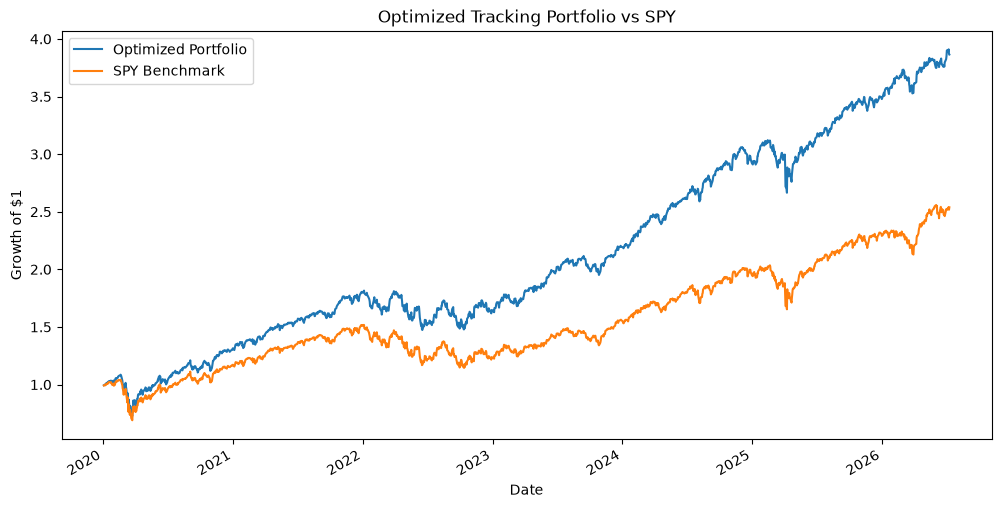

In [16]:
# Step 5: Optimize portfolio weights to minimize tracking error

from scipy.optimize import minimize

# -----------------------------
# 1. Convert returns to NumPy arrays
# -----------------------------

R = stock_returns.values
rb = benchmark_returns.values

n_assets = R.shape[1]

# -----------------------------
# 2. Define objective function
# -----------------------------

def tracking_error_variance(weights):
    """
    Objective function:
    Minimize Var(portfolio returns - benchmark returns)
    """
    portfolio_returns = R @ weights
    active_returns = portfolio_returns - rb
    return np.var(active_returns, ddof=1)

# -----------------------------
# 3. Define constraints
# -----------------------------

constraints = (
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    },
)

# No short selling: each weight must be between 0 and 1
bounds = tuple((0, 1) for _ in range(n_assets))

# Initial guess: equal-weighted portfolio
initial_weights = np.repeat(1 / n_assets, n_assets)

# -----------------------------
# 4. Run optimization
# -----------------------------

result = minimize(
    tracking_error_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

print("Optimization successful:", result.success)
print("Message:", result.message)

# -----------------------------
# 5. Store optimized weights
# -----------------------------

optimal_weights = pd.Series(
    result.x,
    index=universe,
    name="Optimal Weight"
)

optimal_weights = optimal_weights.sort_values(ascending=False)

display(optimal_weights.to_frame())

# -----------------------------
# 6. Check constraints
# -----------------------------

print("Sum of weights:", optimal_weights.sum())
print("Minimum weight:", optimal_weights.min())
print("Maximum weight:", optimal_weights.max())

# -----------------------------
# 7. Compute optimized portfolio returns
# -----------------------------

# Reorder weights to match stock_returns columns
weights_ordered = optimal_weights.reindex(stock_returns.columns).values

portfolio_returns = stock_returns @ weights_ordered
active_returns = portfolio_returns - benchmark_returns

tracking_error_daily = active_returns.std()
tracking_error_annualized = tracking_error_daily * np.sqrt(252)

print("Daily tracking error:", tracking_error_daily)
print("Annualized tracking error:", tracking_error_annualized)

# -----------------------------
# 8. Compare portfolio vs benchmark cumulative returns
# -----------------------------

portfolio_cumulative = (1 + portfolio_returns).cumprod()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

comparison = pd.DataFrame({
    "Optimized Portfolio": portfolio_cumulative,
    "SPY Benchmark": benchmark_cumulative
})

ax = comparison.plot(
    figsize=(12, 6),
    title="Optimized Tracking Portfolio vs SPY"
)

ax.set_ylabel("Growth of $1")

# Step 6: Evaluate the One-Time Optimized Portfolio

The first implementation optimized the portfolio weights once using the full historical sample.

This is useful as a learning exercise, but it is not realistic because it uses the entire dataset to choose weights.

We will evaluate this one-time optimized portfolio using three outputs:

1. A table of portfolio weights.
2. A cumulative return plot comparing the optimized portfolio to SPY.
3. A daily active return plot, where active return is:

$$
r_A = r_p - r_b
$$

4. A rolling tracking error plot, where rolling tracking error is:

$$
TE_t = \sigma(r_p-r_b)
$$

annualized as:

$$
TE_{annualized}=TE_{daily}\sqrt{252}
$$

,Sector,Ticker,Weight,Weight (%)
0,Communication Services,GOOG,0.033333,3.333333
1,Communication Services,META,0.033333,3.333333
28,Communication Services,NFLX,0.033333,3.333333
27,Consumer Discretionary,AMZN,0.033333,3.333333
26,Consumer Discretionary,TSLA,0.033333,3.333333
25,Consumer Discretionary,HD,0.033333,3.333333
24,Consumer Staples,COST,0.033333,3.333333
23,Consumer Staples,WMT,0.033333,3.333333
22,Consumer Staples,PG,0.033333,3.333333
21,Energy,XOM,0.033333,3.333333


One-time daily tracking error: 0.003578826780711418
One-time annualized tracking error: 0.05681211388284182


Text(0.5, 0, 'Date')

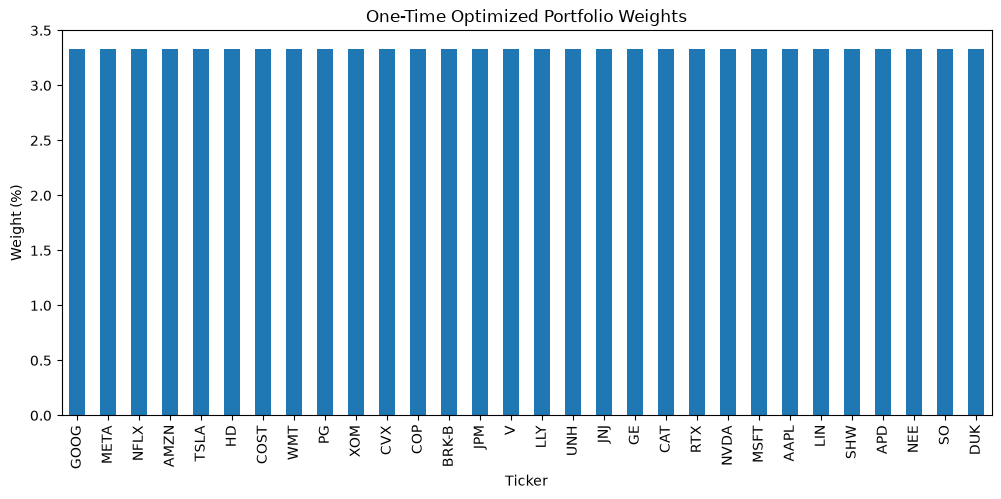

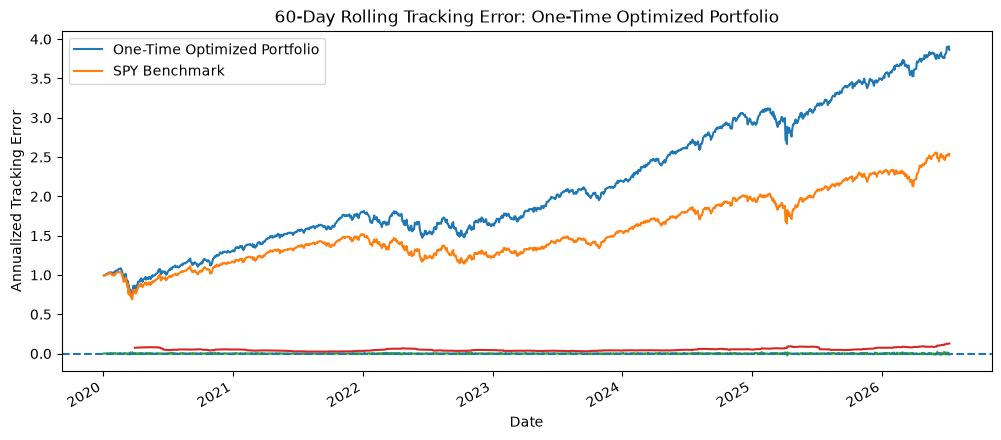

In [17]:
# Step 6: Evaluate one-time optimized portfolio

# --------------------------------------------------
# 1. Portfolio weights table
# --------------------------------------------------

weights_table = (
    pd.DataFrame({
        "Ticker": optimal_weights.index,
        "Weight": optimal_weights.values
    })
    .merge(universe_df, on="Ticker", how="left")
    [["Sector", "Ticker", "Weight"]]
    .sort_values("Weight", ascending=False)
)

weights_table["Weight (%)"] = weights_table["Weight"] * 100

display(weights_table)

# --------------------------------------------------
# 2. Plot optimized weights
# --------------------------------------------------

ax = weights_table.plot(
    x="Ticker",
    y="Weight (%)",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="One-Time Optimized Portfolio Weights"
)

ax.set_ylabel("Weight (%)")
ax.set_xlabel("Ticker")

# --------------------------------------------------
# 3. Portfolio returns, active returns, and tracking error
# --------------------------------------------------

weights_ordered = optimal_weights.reindex(stock_returns.columns).values

one_time_portfolio_returns = stock_returns @ weights_ordered
one_time_active_returns = one_time_portfolio_returns - benchmark_returns

one_time_daily_te = one_time_active_returns.std()
one_time_annual_te = one_time_daily_te * np.sqrt(252)

print("One-time daily tracking error:", one_time_daily_te)
print("One-time annualized tracking error:", one_time_annual_te)

# --------------------------------------------------
# 4. Plot 1: cumulative returns
# --------------------------------------------------

one_time_cumulative = pd.DataFrame({
    "One-Time Optimized Portfolio": (1 + one_time_portfolio_returns).cumprod(),
    "SPY Benchmark": (1 + benchmark_returns).cumprod()
})

ax = one_time_cumulative.plot(
    figsize=(12, 6),
    title="One-Time Optimized Portfolio vs SPY"
)

ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")

# --------------------------------------------------
# 5. Plot 2: daily active returns
# --------------------------------------------------

ax = one_time_active_returns.plot(
    figsize=(12, 5),
    title="Daily Active Returns: One-Time Optimized Portfolio"
)

ax.axhline(0, linestyle="--")
ax.set_ylabel("Active Return")
ax.set_xlabel("Date")

# --------------------------------------------------
# 6. Plot 3: rolling tracking error
# --------------------------------------------------

rolling_window = 60

one_time_rolling_te = (
    one_time_active_returns
    .rolling(rolling_window)
    .std()
    * np.sqrt(252)
)

ax = one_time_rolling_te.plot(
    figsize=(12, 5),
    title=f"{rolling_window}-Day Rolling Tracking Error: One-Time Optimized Portfolio"
)

ax.set_ylabel("Annualized Tracking Error")
ax.set_xlabel("Date")

# Step 7: Rolling Rebalancing Implementation

The one-time optimization used the full sample to choose weights once.

A more realistic approach is to rebalance through time.

At each rebalance date, we will:

1. Look backward over a training window.
2. Estimate the relationship between the stock universe and SPY.
3. Solve for weights that minimize tracking error over the training window.
4. Hold those weights until the next rebalance date.
5. Repeat.

This avoids using future information.

The rolling optimization problem at each rebalance is:

$$
\min_h Var(R_{train}h-r_{b,train})
$$

subject to:

$$
\sum_i h_i=1
$$

and

$$
h_i \ge 0
$$

This creates a time series of portfolio returns that reflects periodic rebalancing.

In [21]:
# Step 7: Rolling rebalancing implementation

from scipy.optimize import minimize

# --------------------------------------------------
# 1. Rebalancing settings
# --------------------------------------------------

lookback_days = 252          # roughly 1 trading year
rebalance_frequency = "ME"   # quarterly end; use "ME" for monthly end

returns_index = stock_returns.index

rebalance_dates = (
    stock_returns
    .resample(rebalance_frequency)
    .last()
    .index
)

# Keep only rebalance dates that exist after enough lookback data
rebalance_dates = [
    date for date in rebalance_dates
    if date in stock_returns.index and stock_returns.index.get_loc(date) >= lookback_days
]

print("Number of rebalance dates:", len(rebalance_dates))
print("First rebalance date:", rebalance_dates[0])
print("Last rebalance date:", rebalance_dates[-1])

# --------------------------------------------------
# 2. Helper function: optimize tracking portfolio
# --------------------------------------------------

def optimize_tracking_portfolio(R_train, rb_train):
    """
    Solves:
        min Var(Rh - rb)

    subject to:
        sum(h) = 1
        h_i >= 0
    """
    n_assets = R_train.shape[1]

    def objective(weights):
        portfolio_returns = R_train @ weights
        active_returns = portfolio_returns - rb_train
        return np.var(active_returns, ddof=1)

    constraints = (
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1
        },
    )

    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_weights = np.repeat(1 / n_assets, n_assets)

    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        print("Warning:", result.message)

    return result.x

# --------------------------------------------------
# 3. Run rolling rebalance backtest
# --------------------------------------------------

rebalanced_returns = pd.Series(index=stock_returns.index, dtype=float)
rebalanced_weights = {}

for i, rebalance_date in enumerate(rebalance_dates):

    rebalance_loc = stock_returns.index.get_loc(rebalance_date)

    train_start_loc = rebalance_loc - lookback_days
    train_end_loc = rebalance_loc

    train_dates = stock_returns.index[train_start_loc:train_end_loc]

    R_train = stock_returns.loc[train_dates].values
    rb_train = benchmark_returns.loc[train_dates].values

    weights = optimize_tracking_portfolio(R_train, rb_train)

    rebalanced_weights[rebalance_date] = weights

    if i < len(rebalance_dates) - 1:
        next_rebalance_date = rebalance_dates[i + 1]
        hold_dates = stock_returns.loc[rebalance_date:next_rebalance_date].index
        hold_dates = hold_dates[1:]
    else:
        hold_dates = stock_returns.loc[rebalance_date:].index
        hold_dates = hold_dates[1:]

    rebalanced_returns.loc[hold_dates] = stock_returns.loc[hold_dates].values @ weights

rebalanced_returns = rebalanced_returns.dropna()

display(rebalanced_returns.head())

# --------------------------------------------------
# 4. Rebalanced portfolio active returns and tracking error
# --------------------------------------------------

aligned_benchmark_returns = benchmark_returns.loc[rebalanced_returns.index]

rebalanced_active_returns = rebalanced_returns - aligned_benchmark_returns

rebalanced_daily_te = rebalanced_active_returns.std()
rebalanced_annual_te = rebalanced_daily_te * np.sqrt(252)

print("Rebalanced daily tracking error:", rebalanced_daily_te)
print("Rebalanced annualized tracking error:", rebalanced_annual_te)

# --------------------------------------------------
# 5. Rebalanced weights table
# --------------------------------------------------

rebalanced_weights_df = pd.DataFrame(
    rebalanced_weights,
    index=stock_returns.columns
).T

display(rebalanced_weights_df.tail())

# --------------------------------------------------
# 6. Turnover at each rebalance
# --------------------------------------------------

turnover = rebalanced_weights_df.diff().abs().sum(axis=1)
turnover = turnover.dropna()

print("Average turnover:", turnover.mean())
display(turnover.to_frame("Turnover").tail())

Number of rebalance dates: 45
First rebalance date: 2021-03-31 00:00:00
Last rebalance date: 2026-06-30 00:00:00


Date
2021-04-01    0.009565
2021-04-05    0.012765
2021-04-06   -0.001696
2021-04-07    0.000892
2021-04-08    0.002847
dtype: float64

Rebalanced daily tracking error: 0.0036170913982783
Rebalanced annualized tracking error: 0.05741954585541159


Ticker,GOOG,META,NFLX,AMZN,TSLA,HD,COST,WMT,PG,XOM,...,RTX,NVDA,MSFT,AAPL,LIN,SHW,APD,NEE,SO,DUK
2025-10-31,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
2025-12-31,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
2026-03-31,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
2026-04-30,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
2026-06-30,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,...,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333


Average turnover: 0.0


,Turnover
2025-10-31,0.0
2025-12-31,0.0
2026-03-31,0.0
2026-04-30,0.0
2026-06-30,0.0


# Step 8: Compare One-Time Optimization vs Rolling Rebalancing

Now we compare the original one-time optimized portfolio against the rolling rebalanced portfolio.

We compare them using the same three diagnostics:

1. Cumulative returns.
2. Daily active returns.
3. Rolling tracking error.

This lets us see whether periodic rebalancing improves the portfolio's ability to track SPY.

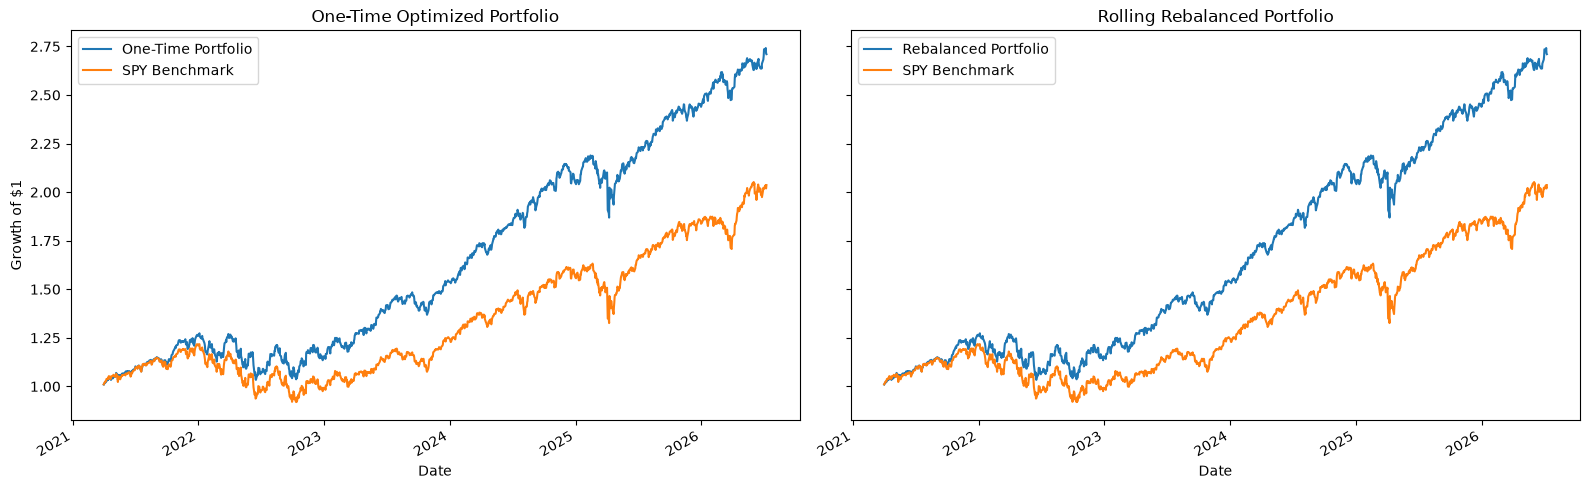

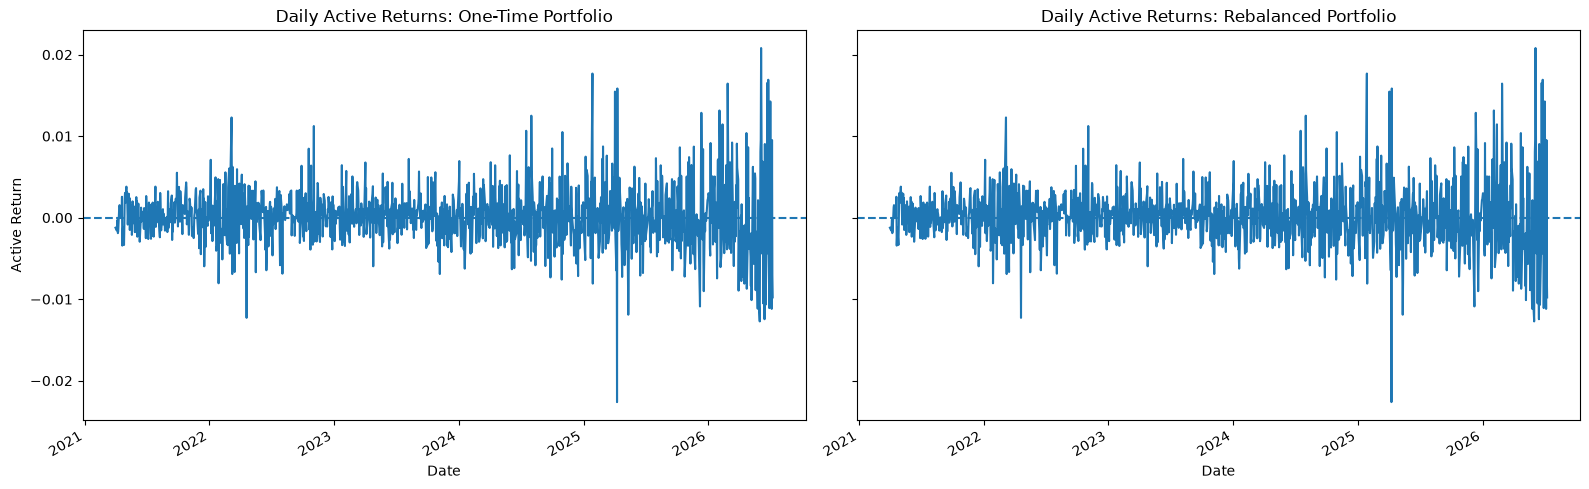

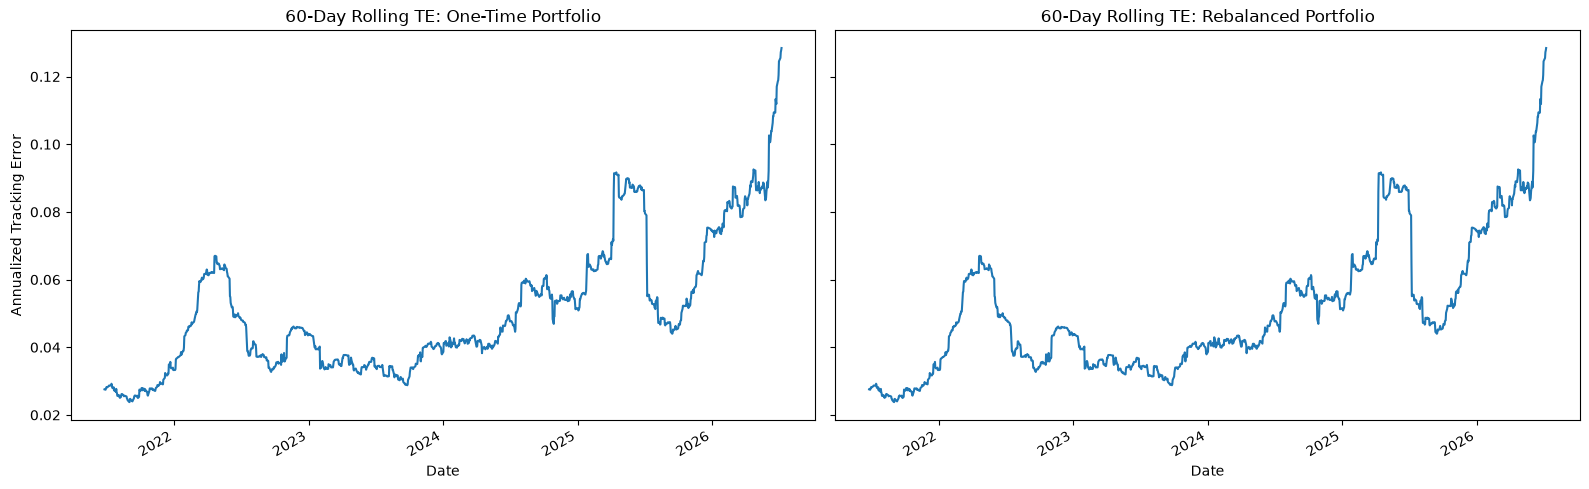

In [19]:
# Step 8: Align one-time and rebalanced portfolios

comparison_index = rebalanced_returns.index

one_time_returns_aligned = one_time_portfolio_returns.loc[comparison_index]
benchmark_returns_aligned = benchmark_returns.loc[comparison_index]

one_time_active_aligned = one_time_returns_aligned - benchmark_returns_aligned
rebalanced_active_aligned = rebalanced_returns - benchmark_returns_aligned

one_time_cum_aligned = (1 + one_time_returns_aligned).cumprod()
rebalanced_cum = (1 + rebalanced_returns).cumprod()
benchmark_cum_aligned = (1 + benchmark_returns_aligned).cumprod()

one_time_rolling_te_aligned = (
    one_time_active_aligned
    .rolling(rolling_window)
    .std()
    * np.sqrt(252)
)

rebalanced_rolling_te = (
    rebalanced_active_aligned
    .rolling(rolling_window)
    .std()
    * np.sqrt(252)
)

# --------------------------------------------------
# 1. Side-by-side plot: cumulative returns
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

pd.DataFrame({
    "One-Time Portfolio": one_time_cum_aligned,
    "SPY Benchmark": benchmark_cum_aligned
}).plot(ax=axes[0], title="One-Time Optimized Portfolio")

pd.DataFrame({
    "Rebalanced Portfolio": rebalanced_cum,
    "SPY Benchmark": benchmark_cum_aligned
}).plot(ax=axes[1], title="Rolling Rebalanced Portfolio")

axes[0].set_ylabel("Growth of $1")
axes[0].set_xlabel("Date")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2. Side-by-side plot: daily active returns
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

one_time_active_aligned.plot(
    ax=axes[0],
    title="Daily Active Returns: One-Time Portfolio"
)

rebalanced_active_aligned.plot(
    ax=axes[1],
    title="Daily Active Returns: Rebalanced Portfolio"
)

axes[0].axhline(0, linestyle="--")
axes[1].axhline(0, linestyle="--")

axes[0].set_ylabel("Active Return")
axes[0].set_xlabel("Date")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. Side-by-side plot: rolling tracking error
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

one_time_rolling_te_aligned.plot(
    ax=axes[0],
    title=f"{rolling_window}-Day Rolling TE: One-Time Portfolio"
)

rebalanced_rolling_te.plot(
    ax=axes[1],
    title=f"{rolling_window}-Day Rolling TE: Rebalanced Portfolio"
)

axes[0].set_ylabel("Annualized Tracking Error")
axes[0].set_xlabel("Date")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()